<a href="https://colab.research.google.com/github/jenny005/Reinforcement-Learning-by-Sutton-Barto/blob/main/Chapter_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Episodic Sarsa in Mountain Car

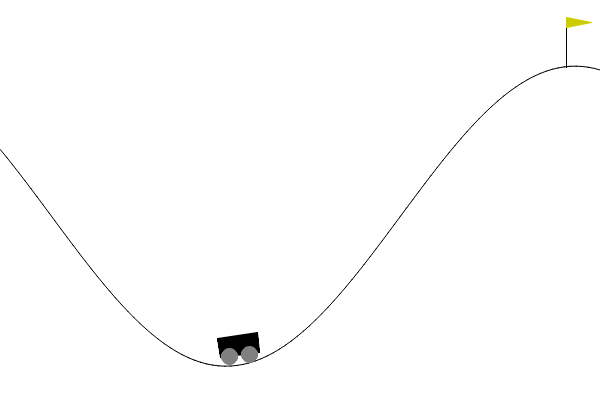

## Tile Coding Episodic Sarsa

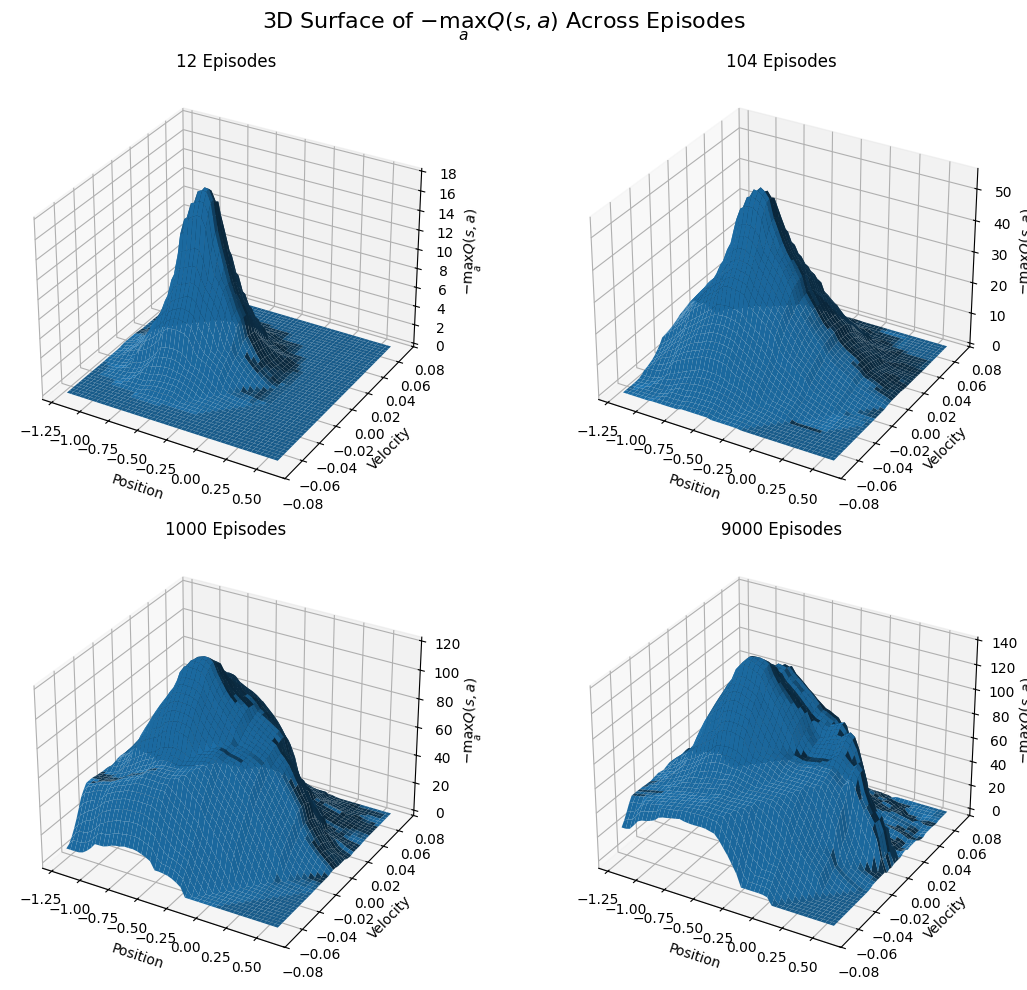

In [ ]:
# Full 3D Surface Plot for -max_a Q(s,a) on MountainCar using Episodic Sarsa
# 8 tilings × 8×8 grid, manual tile‐coding, no external libraries

import numpy as np
# Monkey‐patch for Gym’s old compatibility wrapper
np.bool8 = np.bool_

import gym
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Manual Tile-coder ---
class TileCoder:
    def __init__(self, low, high, num_tilings=8, tiles_per_dim=8):
        self.low = np.array(low, dtype=float)
        self.high = np.array(high, dtype=float)
        self.num_tilings = num_tilings
        self.tiles_per_dim = tiles_per_dim
        self.tile_width = (self.high - self.low) / (tiles_per_dim - 1)
        self.offsets = [(i / num_tilings) * self.tile_width for i in range(num_tilings)]
        self.n_tiles = num_tilings * tiles_per_dim * tiles_per_dim

    def get_tiles(self, obs):
        obs = np.array(obs, dtype=float)
        feats = []
        for t, off in enumerate(self.offsets):
            s = (obs - self.low + off) / self.tile_width
            coords = np.floor(s).astype(int)
            coords = np.clip(coords, 0, self.tiles_per_dim - 1)
            idx = coords[0] * self.tiles_per_dim + coords[1]
            feats.append(t * self.tiles_per_dim * self.tiles_per_dim + idx)
        return feats

# --- Environment setup ---
env = gym.make('MountainCar-v0')
obs_low, obs_high = env.observation_space.low, env.observation_space.high
coder = TileCoder(obs_low, obs_high, num_tilings=8, tiles_per_dim=8)
n_actions = env.action_space.n

alpha, gamma, epsilon = 0.1, 1.0, 0.1

# Epsilon-greedy policy
def choose_action(obs):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    qs = [np.sum(w[a, coder.get_tiles(obs)]) for a in range(n_actions)]
    return int(np.argmax(qs))

# Train Sarsa for a given number of episodes
def train_sarsa(episodes, w):
    for _ in range(episodes):
        reset_out = env.reset()
        obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        obs = np.array(obs, dtype=float)
        a = choose_action(obs)
        feats_old = coder.get_tiles(obs)
        done = False
        while not done:
            step = env.step(a)
            if len(step) == 4:
                obs2, r, done, _ = step
            else:
                obs2, r, term, trunc, _ = step
                done = term or trunc
            obs2 = np.array(obs2, dtype=float)
            if done:
                q_next, feats_next, a2 = 0.0, [], None
            else:
                a2 = choose_action(obs2)
                feats_next = coder.get_tiles(obs2)
                q_next = np.sum(w[a2, feats_next])
            q_old = np.sum(w[a, feats_old])
            delta = r + gamma * q_next - q_old
            for idx in feats_old:
                w[a, idx] += (alpha / coder.num_tilings) * delta
            obs, a, feats_old = obs2, a2, feats_next
    return w

# Episode counts to visualize
episode_list = [12, 104, 1000, 9000]

# Prepare state grid
pos_vals = np.linspace(obs_low[0], obs_high[0], 50)
vel_vals = np.linspace(obs_low[1], obs_high[1], 50)
P, V = np.meshgrid(pos_vals, vel_vals)

# Create subplots
fig, axes = plt.subplots(2, 2, subplot_kw={'projection':'3d'}, figsize=(12, 10))
axes = axes.flatten()

# Loop over episode counts
for ax, ep in zip(axes, episode_list):
    # Initialize weights
    w = np.zeros((n_actions, coder.n_tiles), dtype=float)
    # Train agent
    w = train_sarsa(ep, w)
    # Compute Z matrix for -max Q
    Z = np.zeros_like(P)
    for i in range(len(vel_vals)):
        for j in range(len(pos_vals)):
            state = np.array([P[i, j], V[i, j]], dtype=float)
            qs = [np.sum(w[a, coder.get_tiles(state)]) for a in range(n_actions)]
            Z[i, j] = -max(qs)
    # Plot surface
    ax.plot_surface(P, V, Z, edgecolor='none')
    ax.set_title(f'{ep} Episodes')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_zlabel(r'$-\max_a Q(s,a)$')

fig.suptitle('3D Surface of $-\max_a Q(s,a)$ Across Episodes', fontsize=16)
plt.tight_layout()
plt.show()




## Tabular Discrtization Sarsa

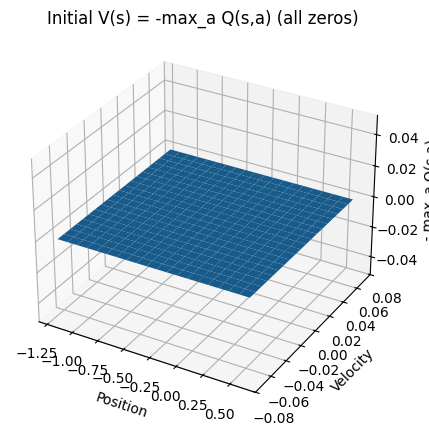

Episode 500/5000
Episode 1000/5000
Episode 1500/5000
Episode 2000/5000
Episode 2500/5000
Episode 3000/5000
Episode 3500/5000
Episode 4000/5000
Episode 4500/5000
Episode 5000/5000


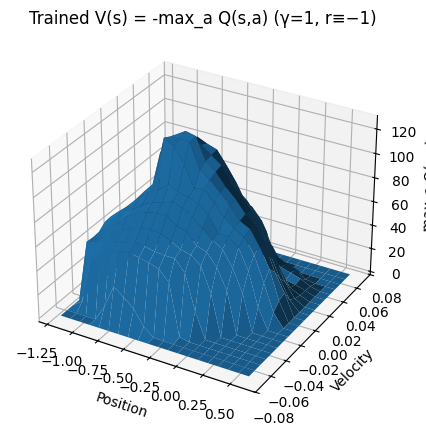

Peak V(s) = 128.30 at position ≈ -0.537, velocity ≈ 0.004


In [ ]:


import numpy as np
# patch Gym–NumPy compatibility
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import gym
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Env + discretization
env = gym.make('MountainCar-v0')
n_actions = env.action_space.n

n_pos_bins = 20
n_vel_bins = 20

pos_bins = np.linspace(env.observation_space.low[0],
                       env.observation_space.high[0],
                       n_pos_bins - 1)
vel_bins = np.linspace(env.observation_space.low[1],
                       env.observation_space.high[1],
                       n_vel_bins - 1)

def discretize(obs):
    p, v = obs
    return (np.digitize(p, pos_bins),
            np.digitize(v, vel_bins))

# 2. Hyperparams (γ=1 so undiscounted)
alpha = 0.1
gamma = 1.0
epsilon = 0.1
n_episodes = 5000
max_steps = 200

# 3. Q-table init
Q = np.zeros((n_pos_bins, n_vel_bins, n_actions))

def choose_action(s):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[s[0], s[1]])

# helper to plot -max Q surface
def plot_neg_max_Q(title):
    negV = -np.max(Q, axis=2)    # shape=(n_pos_bins,n_vel_bins)
    # continuous bin centers
    pos_c = np.linspace(env.observation_space.low[0],
                        env.observation_space.high[0],
                        n_pos_bins)
    vel_c = np.linspace(env.observation_space.low[1],
                        env.observation_space.high[1],
                        n_vel_bins)
    X, Y = np.meshgrid(pos_c, vel_c)
    Z = negV.T  # (n_vel_bins,n_pos_bins)

    fig = plt.figure(figsize=(8,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=True)
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_zlabel('- max_a Q(s,a)')
    ax.set_title(title)
    plt.show()

# 4. Initial surface
plot_neg_max_Q("Initial V(s) = -max_a Q(s,a) (all zeros)")

# 5. SARSA training
for ep in range(n_episodes):
    s = discretize(env.reset())
    a = choose_action(s)
    for t in range(max_steps):
        obs2, r, done, _ = env.step(a)
        s2 = discretize(obs2)
        a2 = choose_action(s2)

        q_old = Q[s[0], s[1], a]
        Q[s[0], s[1], a] += alpha * (r + gamma*Q[s2[0], s2[1], a2] - q_old)

        s, a = s2, a2
        if done:
            break

    if (ep+1) % 500 == 0:
        print(f"Episode {ep+1}/{n_episodes}")

# 6. Final surface
plot_neg_max_Q("Trained V(s) = -max_a Q(s,a) (γ=1, r≡−1)")

# 7. Compute and print the peak value of V(s) and its location
neg_value_table = -np.max(Q, axis=2)  # (n_pos_bins, n_vel_bins)
peak_idx = np.unravel_index(np.argmax(neg_value_table), neg_value_table.shape)
peak_val = neg_value_table[peak_idx]

# map bin‐indices back to continuous centers
pos_centers = np.linspace(env.observation_space.low[0],
                          env.observation_space.high[0],
                          n_pos_bins)
vel_centers = np.linspace(env.observation_space.low[1],
                          env.observation_space.high[1],
                          n_vel_bins)
peak_pos = pos_centers[peak_idx[0]]
peak_vel = vel_centers[peak_idx[1]]

print(f"Peak V(s) = {peak_val:.2f} at position ≈ {peak_pos:.3f}, velocity ≈ {peak_vel:.3f}")

Episode 500/9000
Episode 1000/9000
Episode 1500/9000
Episode 2000/9000
Episode 2500/9000
Episode 3000/9000
Episode 3500/9000
Episode 4000/9000
Episode 4500/9000
Episode 5000/9000
Episode 5500/9000
Episode 6000/9000
Episode 6500/9000
Episode 7000/9000
Episode 7500/9000
Episode 8000/9000
Episode 8500/9000
Episode 9000/9000
Peak V(s) = 193.56 at position ≈ -0.686, velocity ≈ -0.010


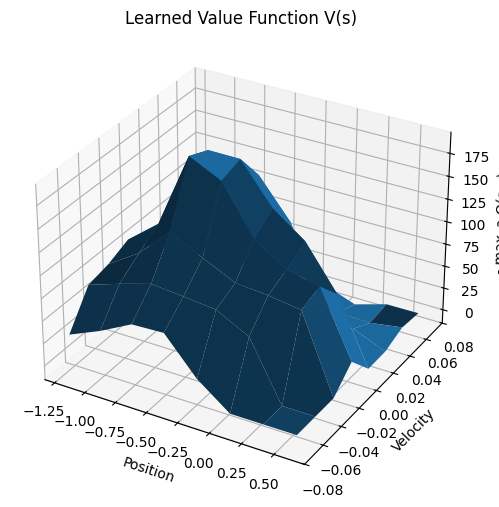

In [3]:
import numpy as np
# Patch for Gym–NumPy compatibility
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import gym
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Tile Coder Definition ---
class TileCoder:
    def __init__(self, lows, highs, tilings=8, bins=(8,8)):
        self.lows = np.array(lows)
        self.highs = np.array(highs)
        self.tilings = tilings
        self.bins = np.array(bins)
        self.tile_width = (self.highs - self.lows) / (self.bins - 1)
        self.offsets = [(i / tilings) * self.tile_width for i in range(tilings)]
        self.tiles_per_tiling = self.bins[0] * self.bins[1]
        self.feature_len = self.tiles_per_tiling * tilings

    def get_features(self, s):
        feats = []
        for t, offset in enumerate(self.offsets):
            coords = (s - self.lows + offset) / self.tile_width
            idxs = np.floor(coords).astype(int)
            idxs = np.clip(idxs, 0, self.bins - 1)
            tile_idx = idxs[0] * self.bins[1] + idxs[1]
            feats.append(t * self.tiles_per_tiling + tile_idx)
        return feats

# --- Environment and Tile Coder Setup ---
env = gym.make('MountainCar-v0')
lows  = env.observation_space.low
highs = env.observation_space.high
n_actions = env.action_space.n

tc = TileCoder(lows, highs, tilings=8, bins=(8,8))
w = np.zeros((tc.feature_len, n_actions))

def Q_hat(s, a):
    return w[tc.get_features(s), a].sum()

def choose_action(s, ε):
    if np.random.rand() < ε:
        return env.action_space.sample()
    qs = [Q_hat(s, a) for a in range(n_actions)]
    return int(np.argmax(qs))

# --- Hyperparameters ---
alpha = 0.1
gamma = 1.0
epsilon = 0.1
n_episodes = 9000
max_steps = 200

# --- Training ---
for ep in range(1, n_episodes+1):
    s = env.reset()
    a = choose_action(s, epsilon)
    for t in range(max_steps):
        s2, r, done, _ = env.step(a)
        a2 = choose_action(s2, epsilon)
        δ = r + gamma * Q_hat(s2, a2) - Q_hat(s, a)
        for feat in tc.get_features(s):
            w[feat, a] += alpha * δ
        s, a = s2, a2
        if done:
            break
    if ep % 500 == 0:
        print(f"Episode {ep}/{n_episodes}")

# --- Compute Value Surface ---
pos_centers = np.linspace(lows[0], highs[0], tc.bins[0])
vel_centers = np.linspace(lows[1], highs[1], tc.bins[1])
V = np.zeros((tc.bins[0], tc.bins[1]))
for i, p in enumerate(pos_centers):
    for j, v in enumerate(vel_centers):
        s = np.array([p, v])
        V[i, j] = -max(Q_hat(s, a) for a in range(n_actions))

# --- Find Peak ---
peak_idx = np.unravel_index(np.argmax(V), V.shape)
peak_val = V[peak_idx]
peak_pos = pos_centers[peak_idx[0]]
peak_vel = vel_centers[peak_idx[1]]
print(f"Peak V(s) = {peak_val:.2f} at position ≈ {peak_pos:.3f}, velocity ≈ {peak_vel:.3f}")

# --- 3D Plot ---
P, VEL = np.meshgrid(pos_centers, vel_centers, indexing='ij')
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(P, VEL, V, rstride=1, cstride=1, linewidth=0, antialiased=True)
ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_zlabel('- max_a Q(s,a)')
ax.set_title('Learned Value Function V(s)')
plt.show()


| Aspect                   | Tile‐Coding Sarsa                                                                                      | Tabular Discretization Sarsa                                                                     |
| ------------------------ | ------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------ |
| **State representation** | 2‑D continuous $(p,v)$ → 8 overlapping 8×8 tilings → 512 binary features per action.                   | 2‑D continuous $(p,v)$ → direct binning into a 20×20 grid → 400 discrete states.                 |
| **Generalization**       | Smooth interpolation across nearby states via overlapping tilings.                                     | “Blocky” constant value within each coarse bin; no sharing across bin boundaries.                |
| **Memory footprint**     | 512 weights per action (1 × 512×3 ≈ 1.5 K parameters).                                                 | 400 Q‑values per action (1 × 400×3 = 1.2 K parameters).                                          |
| **Computational cost**   | Each update sums over 8 active features → O(tilings) per step.                                         | Each update touches exactly one Q‑cell → O(1) per step.                                          |
| **Exploration dynamics** | Optimistic init on continuous features drives systematic “circular” sweeps.                            | Optimistic init (zeros) also drives away from visited bins, but jumps between coarse regions.    |
| **Approximation error**  | Smoother, lower bias for a continuous function; can still mis‐estimate sharp transitions.              | High bias: value surface is piecewise‐constant over each bin, unable to capture fine contours.   |
| **Code complexity**      | A bit more intricate: custom tile‐coder class, feature indexing logic, weight lookups.                 | Simpler: use `np.digitize` for bins and a 3‑D NumPy array for Q.                                 |
| **Visualization**        | 3D surface shows smooth “valley” and ridges.                                                           | 3D surface is stepped, with flat plateaus and abrupt jumps at bin boundaries.                    |
| **When to use**          | When you need continuous‐state learning with generalization, and can afford slightly more computation. | When you want the absolute simplest implementation, or when the state space is naturally coarse. |
